# **Predicting employee churn and retention with Machine Learning **

# Pace: Plan Stage
- Understand the business scenario and goals of analysis



### The business scenario and problem

The HR department at Salifort Motors wants to improve employee satisfaction and retention levels at the company. They collected data from employees, but now they don’t know what to do with it. They have the following question: what’s likely to make the employee leave the company?

The goal is to analyze the data collected by the HR department and build a model that predicts whether or not an employee will leave the company.

It is time-consuming and expensive to find, interview, and hire new employees, so increasing employee retention will be beneficial to the company.

### The HR dataset

The dataset contains 15,000 rows and 10 columns for the variables listed below. 

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)


The stakeholders want to understand how to better retain employees. By analysing employee retention data we can provide them with insights into what factors seem to be associated with employee retention and better enable them to keep employees longer, and with more efficient strategies. 


## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
### Data manipulation packages
import pandas as pd
import numpy as np

### Data visualization package
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns
from xgboost import plot_importance

### Data modelling packages
# Regression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression 

# Machine learning
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### Data model performance metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

### To save fit models
import pickle

In [2]:
# Load data. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv('HR_dataset.csv')


# Display first few rows of the dataframe
### YOUR CODE HERE ###
df0.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

In [3]:
# Gather basic information about the data
df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
df0.describe()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


We will rename the columns so they are standardized ('snake_case'), concise, and free of mistakes. 

In [5]:
# Display all column names
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [13]:
# Rename columns as needed
df1 = df0

df1.rename(columns={'Work_accident':'work_accident',\
                    'Department':'department',\
                    'average_montly_hours':'average_monthly_hours',\
                    'promotion_last_5years':'recent_promotion',\
                   'time_spend_company':'years_employed'}, inplace=True)


# Display all column names after the update
df1.head(10)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,years_employed,work_accident,left,recent_promotion,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


### Check missing values

Check for any missing values in the data.

In [7]:
# Check for missing values
df1.isna().sum()


satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
years_employed           0
work_accident            0
left                     0
recent_promotion         0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [8]:
# Check for duplicates
df1.duplicated().sum()


np.int64(3008)

In [9]:
# Inspect some rows containing duplicates as needed
df1[df1.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,years_employed,work_accident,left,recent_promotion,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [10]:
# Check if there is an imbalance across the target variable 'left'
df1[df1.duplicated()]['left'].value_counts()

left
1    1580
0    1428
Name: count, dtype: int64

In [14]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df2 = df1.drop_duplicates()


# Display first few rows of new dataframe as needed
df2.shape


(11991, 10)

### Check outliers

Check for outliers in the data.

<Axes: xlabel='years_employed'>

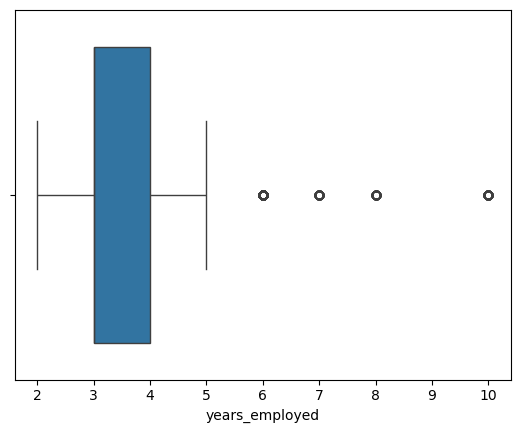

In [12]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers

sns.boxplot(x=df2['years_employed'])

In [15]:
# Determine the number of rows containing outliers

print(df2['years_employed'].describe())

# 25th quintile is 3, 75th quintile is 4. So IQR is 1. 
# Upper outlier limit is the 75th quintile plus 1.5*IQR which is 1.5*1 = 1.5
# Lower outlier limit is the 25th quintile minus 1.5
outlier_upper = 4 + 1.5
outlier_lower = 3 - 1.5

df2[(df2['years_employed']>outlier_upper) | (df2['years_employed']<outlier_lower)].shape



count    11991.000000
mean         3.364857
std          1.330240
min          2.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         10.000000
Name: years_employed, dtype: float64


(824, 10)

Certain types of models are more sensitive to outliers than others. We will decide whether to remove outliers based on the type of model we use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



## Step 2. Data Exploration (Continue EDA)

How many employees left and what percentage of all employees does this represent?

In [14]:
# Get numbers of people who left vs. stayed

print(df2['left'].value_counts())

# Get percentages of people who left vs. stayed

df2['left'].value_counts(normalize=True)

0    10000
,1     1991
,Name: left, dtype: int64


0    0.833959
1    0.166041
Name: left, dtype: float64

### Data visualizations

Create plots to visualize relationships between useful variables in the data.

Text(0.5, 1.0, 'Satisfaction level vs Average monthly hours')

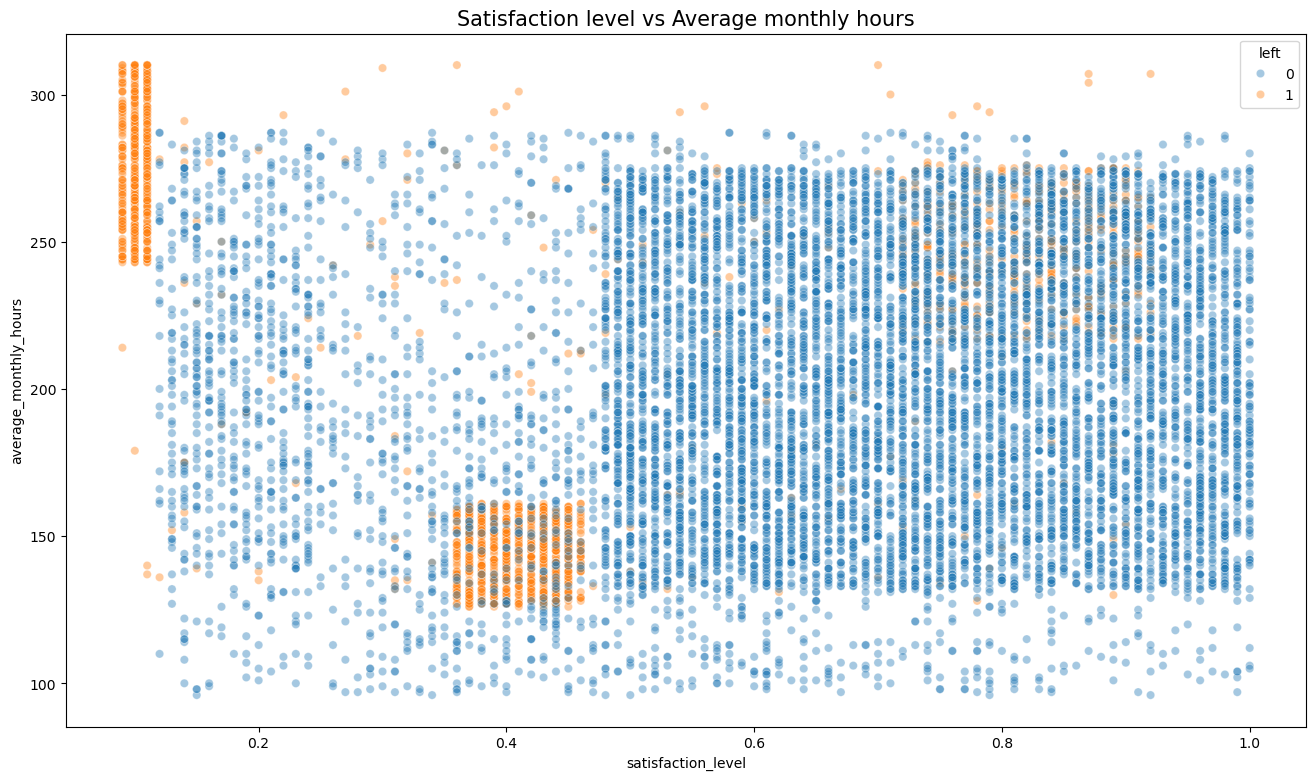

In [16]:
# Plot of satisfaction level,  average monthly hours worked, and target variable 'left'

plt.figure(figsize=(16,9))
sns.scatterplot(x=df2['satisfaction_level'], y=df2['average_monthly_hours'], hue=df2['left'],alpha=0.4)
plt.title('Satisfaction level vs Average monthly hours', fontsize = 15)

In [ ]:
#Note the two distinct groups of employees who left:
# Those with a satisfaction level around 0.4 and average monthly hours of 150
# Those with a satisfaction level of almost 0, and very high average monthly hours of 250 to 300

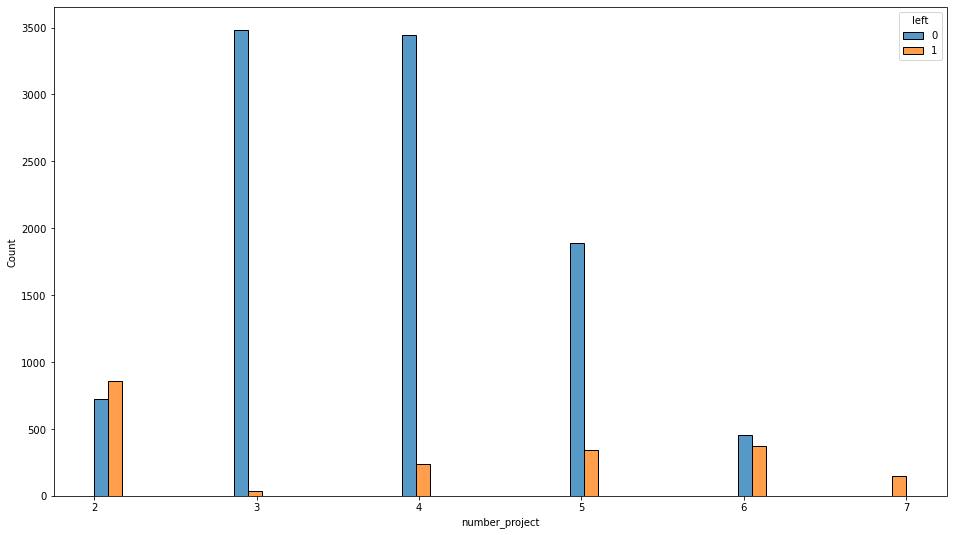

In [16]:
# Histogram of number of employees who stayed/left at each level of number of projects
plt.figure(figsize=(16,9))
sns.histplot(x=df2['number_project'], hue=df2['left'], multiple='dodge')


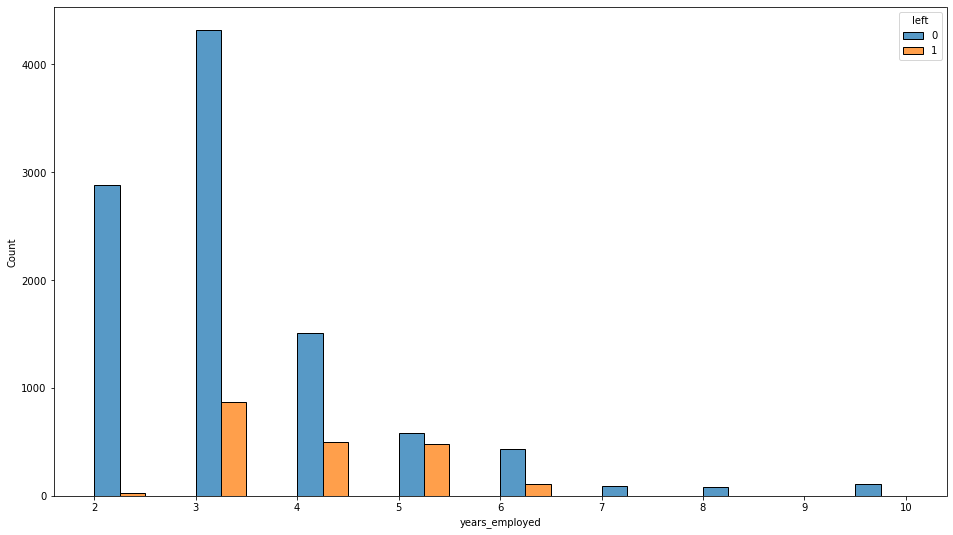

In [17]:
# histogram of number of employees who stayed/left at each level of years employed
plt.figure(figsize=(16,9))
sns.histplot(x=df2['years_employed'], hue=df2['left'], multiple='dodge', binwidth=0.5)


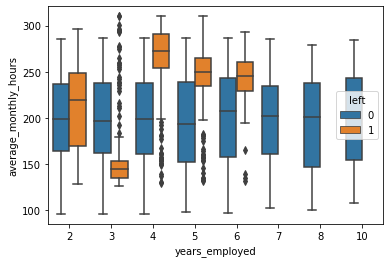

In [18]:
# Box plot of average monthly hours for each year of employment colored by left/stayed

sns.boxplot(data=df2, x='years_employed', y='average_monthly_hours', hue='left')


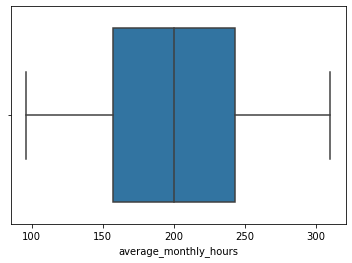

In [19]:
# Box plot of average_monthly_hours to see overall mean and IQR 

sns.boxplot(data=df2, x='average_monthly_hours', hue='left')

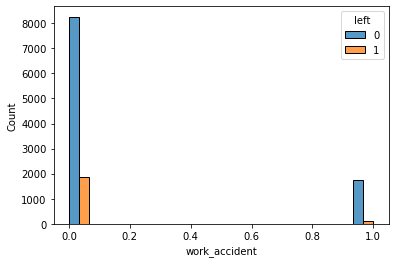

In [20]:
# Histogram of number of employees that had or did not have a work accident and whether they left

sns.histplot(data=df2, x='work_accident', hue='left', multiple='dodge')

In [17]:
# Count of how many employees were or were not recently promoted
# N.B. recently means within the last 5 years
df2.columns
df2['recent_promotion'].value_counts()

recent_promotion
0    11788
1      203
Name: count, dtype: int64

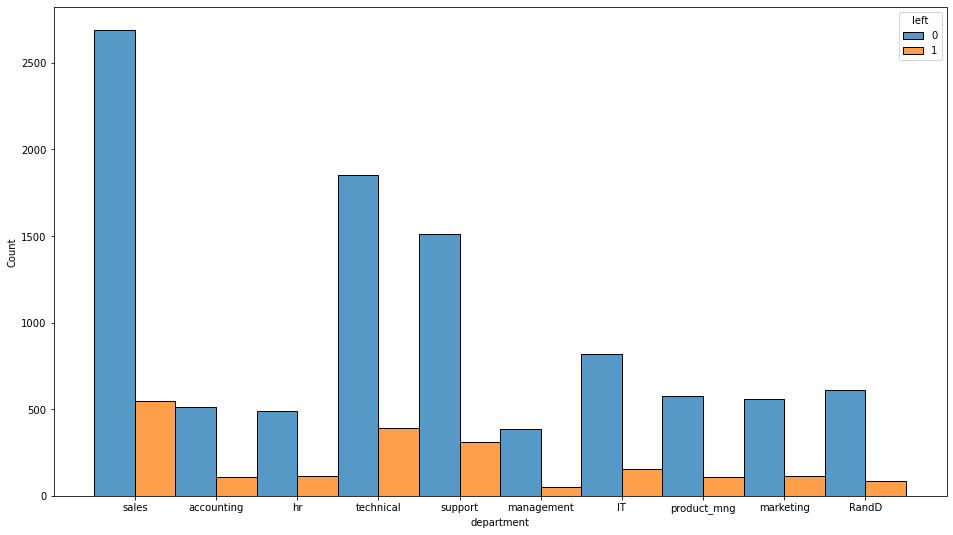

In [22]:
# Histogram of employee counts by department and colored by whether employees left or not
plt.figure(figsize=(16,9))
sns.histplot(data=df2, x='department', hue='left', multiple='dodge')



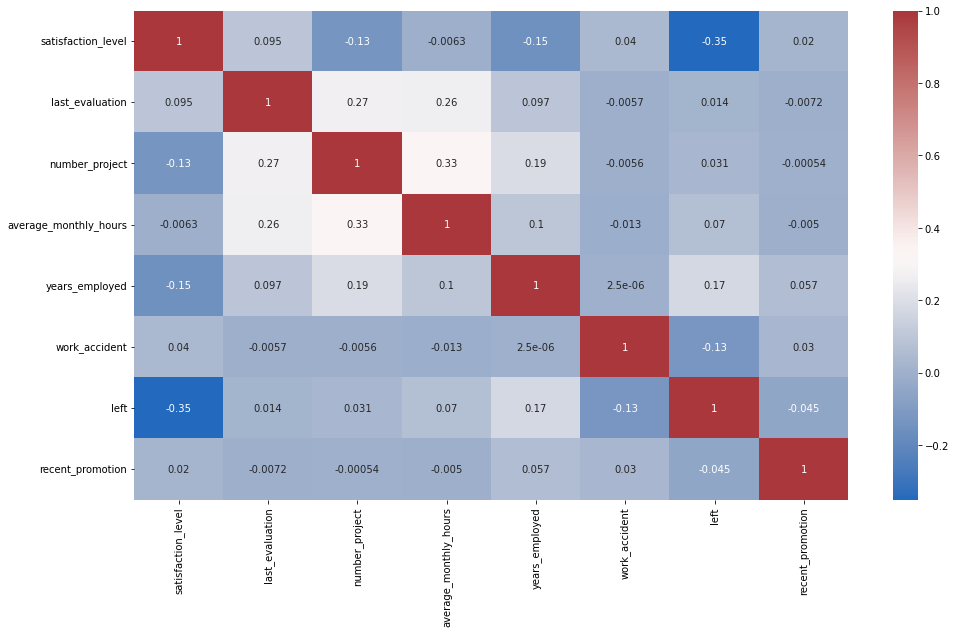

In [23]:
# Plot of all correlations between variables

plt.figure(figsize=(16,9))
sns.heatmap(df2.corr(), annot=True, cmap=sns.color_palette('vlag', as_cmap=True))


### Insights

There are a few modest correlations between the target variable and other variables. As you would expect, satisfaction level negatively correlates with an employee leaving, counterintuitively having a work accident also seems to negatively correlate with an employee leaving, and the number of years an employee is employed positively correlates with an employee leaving the company. These are all simple, bivariate correlations.  

The data visualizations of the relationships between variables and with the target variable suggest that variables may have interactive and non-linear effects. That is, variables differently correlate with each other depending on the level of other variables. For example, average monthly hours has quite a low bivariate correlation with the 'left' target variable, but the visualization of average monhtly hours, satisfaction level, and the 'left' target variable suggest that a very large number of employees with particularly high average monthly hours and particularly low satisfaction levels left the company, but the correlation at other levels of average monthly hours was more random. 

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Modeling

## We will compare Logistic Regression, Random Forest, and XGBoost model performance and select a champion

In [18]:
### Logistic Regression Modelling ###
## Step 1 - Impute outliers ##

for column in ['years_employed']:
    threshold = df2[column].quantile(0.95)
    df2.loc[df2[column] > threshold, column] = threshold

    
df2.describe()

#Outlier values in the 'years_employed' column are replaced with the 95th quantile, which is 6. Previous max value was 10

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,years_employed,work_accident,left,recent_promotion
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.307814,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.134891,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,6.000000,1.000000,1.000000,1.000000


In [19]:
##Step 2 - encode categorical variables to binary variables and ordinal categorical variable to ordinal numeric##

encoder = OrdinalEncoder(categories = [['low', 'medium', 'high']])
df2['salary_encoded'] = encoder.fit_transform(df2[['salary']])

#Make copy of df2#
df2_encoded = df2

#Drop the original salary column so there is only the encoded salary column#
df2_encoded.drop(columns=['salary'], axis=1, inplace=True)

#Encode the department variable with getdummies#
df2_encoded = pd.get_dummies(df2_encoded, drop_first=False)

df2_encoded.head(10)

<ipython-input-19-22c787ba914f>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['salary_encoded'] = encoder.fit_transform(df2[['salary']])
<ipython-input-19-22c787ba914f>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_encoded.drop(columns=['salary'], axis=1, inplace=True)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,years_employed,work_accident,left,recent_promotion,salary_encoded,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0.0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1.0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1.0,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0.0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0.0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,1,0,0.0,False,False,False,False,False,False,False,True,False,False
6,0.10,0.77,6,247,4,0,1,0,0.0,False,False,False,False,False,False,False,True,False,False
7,0.92,0.85,5,259,5,0,1,0,0.0,False,False,False,False,False,False,False,True,False,False
8,0.89,1.00,5,224,5,0,1,0,0.0,False,False,False,False,False,False,False,True,False,False
9,0.42,0.53,2,142,3,0,1,0,0.0,False,False,False,False,False,False,False,True,False,False


In [20]:
##Create the X and y variables

X = df2_encoded.drop(columns =['left'], axis = 1)
y = df2_encoded['left']

In [21]:
##Make initial split for training, validation, and test subsets

X_tr, X_test, y_tr, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

## Split again into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.25, stratify=y_tr, random_state=42)

In [22]:
##instantiate the model
##was getting an error that said "AttributeError: 'str' object has no attribute 'decode'" that seems to be an error
##with the default solver type an something to do with trying to decode (encode numerically?) already decoded variables
##changing the solver to 'liblinear' another solver the documentation suggests for large datasets worked

logreg_clf = LogisticRegression(solver='liblinear').fit(X_train, y_train)

In [23]:
##get predictions using X_test data

y_pred = logreg_clf.predict(X_val)

In [24]:
## Get model validation results and interpret performance

print("Accuracy score: ", accuracy_score(y_val, y_pred))
print("Recall score: ", recall_score(y_val, y_pred))
print("Precision score: ", precision_score(y_val, y_pred))
print("F1 score: ", f1_score(y_val, y_pred))

Accuracy score:  0.8311092577147623
Recall score:  0.18592964824120603
Precision score:  0.4774193548387097
F1 score:  0.26763110307414106


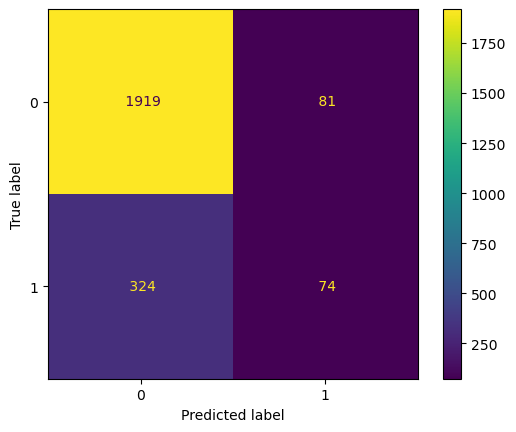

In [25]:
## Visualize the Logistic Regression Results with a Confusion Matrix

cm = confusion_matrix(y_val, y_pred)

CMD = ConfusionMatrixDisplay(cm, display_labels=logreg_clf.classes_) 

CMD.plot(values_format=' ') ##remove scientific notation for the numbers displayed

# The logistic regression classifier - results and evaluation

#### The logistic regression classifier has quite poor recall (19%) and precision (48%). 
#### Its accuracy is relatively high at 83%, but this is mostly due to correctly predicting those who did not leave. 
#### It does not predict those who do leave well. As such, we will try using an alternative model,
#### such as a random forest. 

# Random Forest Modelling #

In [26]:
##instatiate the model
#NOTE: We want to refit optimizing for f1. I think f1 is best because accurately predicting 
#those who will leave (recall) is most important, but accurately predicting those who will not leave (precision)
#is also useful, but somewhat less so. Ideally we want to minimize false positives, but it is not critical.  

RF_clf = RandomForestClassifier(random_state = 42)

#create a dictionary of hypermaraters to tune with GridSearch
cv_params = {'max_depth': [None],
            'max_features': ['sqrt'],
            'min_samples_leaf': [1,2],
            'min_samples_split': [0.001, 0.01],
            'n_estimators': [50, 100]}

#create a list of scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

#instatiate the GridSearchCV object

RF_clf_cv = GridSearchCV(RF_clf, cv_params, scoring=scoring, cv=5, refit='f1')

In [27]:
%%time
RF_clf_cv.fit(X_train, y_train)

CPU times: user 30.2 s, sys: 0 ns, total: 30.2 s
Wall time: 30.2 s


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [0.001, 0.01], ...}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [28]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy',
                   'auc': 'mean_test_roc_auc'
                   }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
    auc = best_estimator_results.mean_test_roc_auc

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'auc': [auc]},
                         )

    return table

In [29]:
RF_results = make_results('Random Forest CV', RF_clf_cv, 'f1')

RF_results

,model,precision,recall,F1,accuracy,auc
0,Random Forest CV,0.986529,0.904603,0.94354,0.982068,0.977722


# XGBoost Modelling

In [30]:
#instantiate the model

XGB_clf = XGBClassifier(objective='binary:logistic', random_state=42)

#Define hyperparameters and scoring

cv_params= {'max_depth': [3,6],
           'min_child_weight': [3],
           'learning_rate': [0.1],
           'n_estimators': [5,10],
           'subsample': [0.7],
           'colsample_bytree': [0.7]}

scoring = ['accuracy', 'recall', 'precision', 'f1', 'roc_auc']

#instatiate the grid search object

XGB_clf_cv = GridSearchCV(XGB_clf, cv_params, scoring=scoring, cv=5, refit='f1')

In [33]:
%%time
#fit the GridSearch model to training data

XGB_clf_cv.fit(X_train, y_train)

CPU times: user 3.13 s, sys: 0 ns, total: 3.13 s
Wall time: 3.13 s


,estimator,"XGBClassifier...state=42, ...)"
,param_grid,"{'colsample_bytree': [0.7], 'learning_rate': [0.1], 'max_depth': [3, 6], 'min_child_weight': [3], ...}"
,scoring,"['accuracy', 'recall', ...]"
,n_jobs,None
,refit,'f1'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [34]:
XGB_clf_cv.best_score_

np.float64(0.9172801589767381)

In [42]:
XGB_results = make_results('XGBoost CV', XGB_clf_cv, 'f1')

results_table = pd.concat([RF_results, XGB_results])

results_table

,model,precision,recall,F1,accuracy,auc
0,Random Forest CV,0.986529,0.904603,0.94354,0.982068,0.977722
0,XGBoost CV,0.992575,0.853556,0.91728,0.974562,0.974619


In [43]:
#add Logistic Regression Classifier Training and Validation results

logreg_train_pred = logreg_clf.predict(X_train)

LogReg_train_results = pd.DataFrame({'model': ['Logistic Regression Training'],
                     'precision': [precision_score(y_train, logreg_train_pred)],
                     'recall': [recall_score(y_train, logreg_train_pred)],
                    'accuracy': [accuracy_score(y_train, logreg_train_pred)],
                     'F1': [f1_score(y_train, logreg_train_pred)],
                     'auc': [roc_auc_score(y_train, logreg_train_pred)]})

results_table = pd.concat([results_table, LogReg_train_results])


LogReg_results = pd.DataFrame({'model': ['Logistic Regression Validation'],
                     'precision': [precision_score(y_val, y_pred)],
                     'recall': [recall_score(y_val, y_pred)],
                    'accuracy': [accuracy_score(y_val, y_pred)],
                     'F1': [f1_score(y_val, y_pred)],
                     'auc': [roc_auc_score(y_val, y_pred)]})

results_table = pd.concat([results_table, LogReg_results])

results_table

,model,precision,recall,F1,accuracy,auc
0,Random Forest CV,0.986529,0.904603,0.943540,0.982068,0.977722
0,XGBoost CV,0.992575,0.853556,0.917280,0.974562,0.974619
0,Logistic Regression Training,0.405579,0.158159,0.227574,0.821657,0.555992
0,Logistic Regression Validation,0.477419,0.185930,0.267631,0.831109,0.572715


In [44]:
## Get Random Forest Model Validation Scores

RF_pred = RF_clf_cv.predict(X_val)

RF_val_results = pd.DataFrame({'model': ['Random Forest Validation'],
                     'precision': [precision_score(y_val, RF_pred)],
                     'recall': [recall_score(y_val, RF_pred)],
                    'accuracy': [accuracy_score(y_val, RF_pred)],
                     'F1': [f1_score(y_val, RF_pred)],
                     'auc': [roc_auc_score(y_val, RF_pred)]})

results_table = pd.concat([results_table, RF_val_results])

results_table

,model,precision,recall,F1,accuracy,auc
0,Random Forest CV,0.986529,0.904603,0.943540,0.982068,0.977722
0,XGBoost CV,0.992575,0.853556,0.917280,0.974562,0.974619
0,Logistic Regression Training,0.405579,0.158159,0.227574,0.821657,0.555992
0,Logistic Regression Validation,0.477419,0.185930,0.267631,0.831109,0.572715
0,Random Forest Validation,0.981132,0.914573,0.946684,0.982902,0.955536


In [45]:
## Get XGBoost Model Validation Scores

XGB_pred =XGB_clf_cv.predict(X_val)

XGB_val_results = pd.DataFrame({'model': ['XGBoost Validation'],
                     'precision': [precision_score(y_val, XGB_pred)],
                     'recall': [recall_score(y_val, XGB_pred)],
                    'accuracy': [accuracy_score(y_val, XGB_pred)],
                     'F1': [f1_score(y_val, XGB_pred)],
                     'auc': [roc_auc_score(y_val, XGB_pred)]})

results_table = pd.concat([results_table, XGB_val_results])

results_table

,model,precision,recall,F1,accuracy,auc
0,Random Forest CV,0.986529,0.904603,0.943540,0.982068,0.977722
0,XGBoost CV,0.992575,0.853556,0.917280,0.974562,0.974619
0,Logistic Regression Training,0.405579,0.158159,0.227574,0.821657,0.555992
0,Logistic Regression Validation,0.477419,0.185930,0.267631,0.831109,0.572715
0,Random Forest Validation,0.981132,0.914573,0.946684,0.982902,0.955536
0,XGBoost Validation,0.991279,0.856784,0.919137,0.974979,0.927642


# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



In [45]:
## Based on the validation performance of the models shown above, Random Forest and XGBoost models perform best.
## They are similar, but the Random Forest Model is slightly better.
## We will select the Random Forest Model as our champion model and test it using the test holdout data. 

In [46]:
# Get predicted Y values from the test dataset using the Random Forest Model 

RF_pred_test = RF_clf_cv.predict(X_test)

# Get performance metrics 

RF_test_results = pd.DataFrame({'model': ['Random Forest Test'],
                     'precision': [precision_score(y_test, RF_pred_test)],
                     'recall': [recall_score(y_test, RF_pred_test)],
                    'accuracy': [accuracy_score(y_test, RF_pred_test)],
                     'F1': [f1_score(y_test, RF_pred_test)],
                     'auc': [roc_auc_score(y_test, RF_pred_test)]})

results_table = pd.concat([results_table, RF_test_results])

results_table

,model,precision,recall,F1,accuracy,auc
0,Random Forest CV,0.986529,0.904603,0.943540,0.982068,0.977722
0,XGBoost CV,0.992575,0.853556,0.917280,0.974562,0.974619
0,Logistic Regression Training,0.405579,0.158159,0.227574,0.821657,0.555992
0,Logistic Regression Validation,0.477419,0.185930,0.267631,0.831109,0.572715
0,Random Forest Validation,0.981132,0.914573,0.946684,0.982902,0.955536
0,XGBoost Validation,0.991279,0.856784,0.919137,0.974979,0.927642
0,Random Forest Test,0.983957,0.924623,0.953368,0.984994,0.960812


In [47]:
## The Random Forest test data performance is consist with training and validation, with a slight improvement. 
## Recall is at 92.5% meaning that 92.5% of people who actually left the company were correctly predicted to be
## leavers by the model. Precision is at 98.5%, meaning that 98.5% of the people the model predicted would leave 
## did in fact leave the company. 

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders



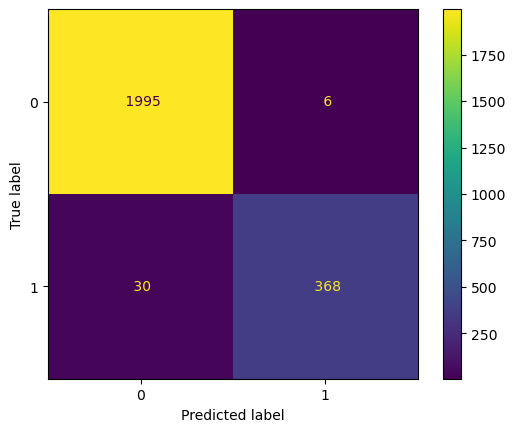

In [47]:
# Create confusion matrix

CM = confusion_matrix(y_test, RF_pred_test, labels=RF_clf_cv.classes_)

CM_disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=RF_clf_cv.classes_)

CM_disp.plot(values_format =' ')

### From the confusion matrix we can see that the Random Forest Model did a very good job of predicting those who would and would not leave. 
### 1995 people who did not leave were correctly predicted to not leave (True negatives)
### and only 6 were predicted to leave who did not (False positives).
### 368 who left were correctly predicted to leave (True positives)
### and only 30 were predicted not to leave who actually did leave (False negatives). 

                        gini_importance
,satisfaction_level             0.362373
,number_project                 0.176395
,years_employed                 0.155785
,average_monthly_hours          0.139888
,last_evaluation                0.134710
,salary_encoded                 0.008918
,work_accident                  0.006750
,department_technical           0.002031
,department_sales               0.001791
,department_support             0.001763
,department_management          0.001654
,department_IT                  0.001528
,department_marketing           0.001306
,department_hr                  0.001277
,recent_promotion               0.001147
,department_RandD               0.001130
,department_accounting          0.000833
,department_product_mng         0.000722


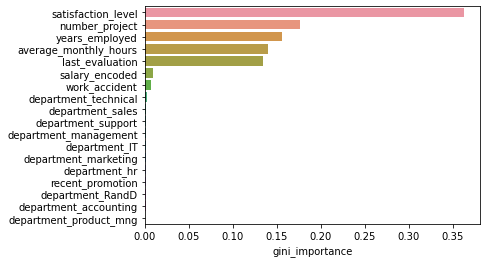

In [49]:
#Get feature importances

RF_importances = pd.DataFrame(RF_clf_cv.best_estimator_.feature_importances_, columns=['gini_importance'],
            index=X.columns)

RF_importances = RF_importances.sort_values(by='gini_importance', ascending=False)

print(RF_importances)

#Plot feature importances

RF_importances_plot = sns.barplot(data=RF_importances, y=RF_importances.index, x='gini_importance')

 
1) Key Insights: As shown by their gini importance scores, key features for predicting employees who leave are: 
    a) satisfaction levell
    b) number of projects
    c) years employed
    d) average monthly hours 
    e) last evaluation
    
2) Recommendations and avenues for further investigation: In exploratory data exploration we saw that employees who had long tenures over 4 years, tended to be satisfied and not leave. Further, employees who had six or seven projects and were working large numbers of hours each month were very likely to leave. These factors warrant further investigation. 

 - It would be worth understanding some more details about the employees who had long tenures and did not leave - were they promoted? Did they have higher salaries? Salary did not seem to be an important feature in the model, but seniority or job title may be. 
 - People working too many hours and having too many projects also seemed to leave much more frequently. It could be worth investigating ways to mitigate this to increase retention. For example, introducing project number caps, and other methods for sharing project load equitably between employees may be worthwhile avenues of investigation.
 - Average monthly hours worked is an important feature in the model, but perhaps the model could be improved by further feature engineering and splitting average monthly hours into an ordinal feature with low/underworked, medium, and high/overworked categories. 
 - As a whole, many employees seem to be working long hours, with a median monthly worked hours of about 200 hours. This combined with the fact that the department an employee was in did not seem to impact them leaving, shows that increasing retention is a whole of organization task. 

3) Limitations of the models and findings
- The models were built with data that were collected over months and years. Given the goal is to predict which employees might be likely to leave before they do leave, it might not make sense to overly rely on data that can only be built up over time such as satisfaction ratings and evaluation scores. Clearly, dissatisfied and poorly evaluated employees are more likely to leave or be fired, but the goal is to use the model to predict and act before this becomes the case. 



